In [4]:
import pandas as pd
import seaborn as sns

# the one and only network load for the whole project - everything
# after this point works off the saved CSV, never calls this again
df = sns.load_dataset('titanic')

# save immediately, before any cleaning/processing, so grading can run
# offline via pd.read_csv("titanic.csv") if sns.load_dataset can't reach
# the network at grading time
df.to_csv("titanic.csv", index=False)

print("Shape:", df.shape)

Shape: (891, 15)


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [3]:
print(df.describe())

         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200


In [5]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage = missing_percentage[missing_percentage > 0].sort_values(ascending=False)

print("Columns with missing values (%):")
print(missing_percentage)

Columns with missing values (%):
deck           77.216611
age            19.865320
embarked        0.224467
embark_town     0.224467
dtype: float64


In [6]:
print(df["deck"].unique())


[NaN, 'C', 'E', 'G', 'D', 'A', 'B', 'F']
Categories (7, str): ['A', 'B', 'C', 'D', 'E', 'F', 'G']


In [7]:
#Since the missing values are greater than 30% without randomness, remove the col from dataset 
df = df.drop(columns=["deck"])
print("Remaining columns:", df.columns.tolist())

Remaining columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone']


In [10]:
# fill missing age with the median age within each pclass+sex group,
# since typical age varies a lot by class and gender on this dataset
before_missing = df["age"].isnull().sum()

# compute median age per pclass+sex group
group_medians = df.groupby(["pclass", "sex"])["age"].median().reset_index()
group_medians.columns = ["pclass", "sex", "age_median"]

# attach each row's group median as a new column
df = df.merge(group_medians, on=["pclass", "sex"], how="left")

# fill missing age using the attached group median, then drop the helper column
df["age"] = df["age"].fillna(df["age_median"])
df = df.drop(columns=["age_median"])

after_missing = df["age"].isnull().sum()
print(f"Missing age before: {before_missing}")
print(f"Missing age after: {after_missing}")

Missing age before: 177
Missing age after: 0


In [12]:
print("embarked unique values:", df["embarked"].unique())
print("embark_town unique values:", df["embark_town"].unique())

embarked unique values: <StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str
embark_town unique values: <StringArray>
['Southampton', 'Cherbourg', 'Queenstown', nan]
Length: 4, dtype: str


In [ ]:
#since the embarked col has the values with the first letter of the values of embarked town 
#so dropping the embarked town col

df = df.drop(columns=["embark_town"])
print("Remaining columns:", df.columns.tolist())

Remaining columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'alive', 'alone']


In [ ]:
before_rows = len(df)
#Since there are only 2 empty values in embarked col,deleting those two rows which doesnot affect remaining data

df = df.dropna(subset=["embarked"])

after_rows = len(df)
print(f"Rows before: {before_rows}")
print(f"Rows after: {after_rows}")
print(f"Rows dropped: {before_rows - after_rows}")

Rows before: 891
Rows after: 889
Rows dropped: 2


In [15]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage = missing_percentage[missing_percentage > 0].sort_values(ascending=False)

print("Columns with missing values (%):")
print(missing_percentage)

Columns with missing values (%):
Series([], dtype: float64)


In [ ]:
#since the survived col has the values with 0 or 1 if the values of alive(0-no,1-yes) so drop alive col

df = df.drop(columns=["alive"])
print("Remaining columns:", df.columns.tolist())

Remaining columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'alone']


In [19]:
print(df["survived"].unique())
print(df["adult_male"].unique())
df["who"].unique()


[0 1]
[ True False]


<StringArray>
['man', 'woman', 'child']
Length: 3, dtype: str

In [ ]:
#since the sex col has the values with male or female if the values of adult_male(False-female,True-male) so drop adult_male col

df = df.drop(columns=["adult_male"])
print("Remaining columns:", df.columns.tolist())

Remaining columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'alone']


In [21]:
#since the pclass col has the values 1,2,3 if the values of class(1-first,2-second,3-third) so drop class col

df = df.drop(columns=["class"])
print("Remaining columns:", df.columns.tolist())

Remaining columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'who', 'alone']


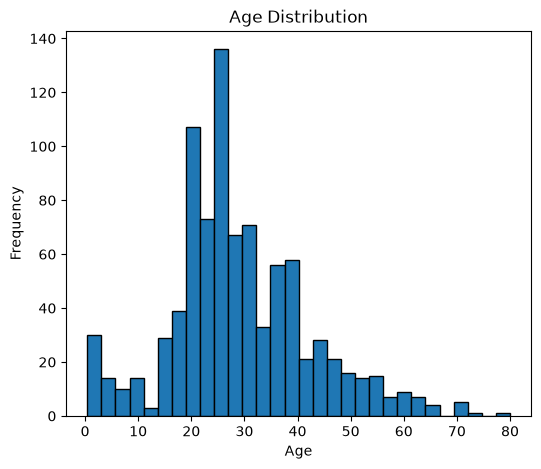

In [22]:

import matplotlib.pyplot as plt
plt.figure(figsize=(6, 5))
plt.hist(df["age"], bins=30, edgecolor="black")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

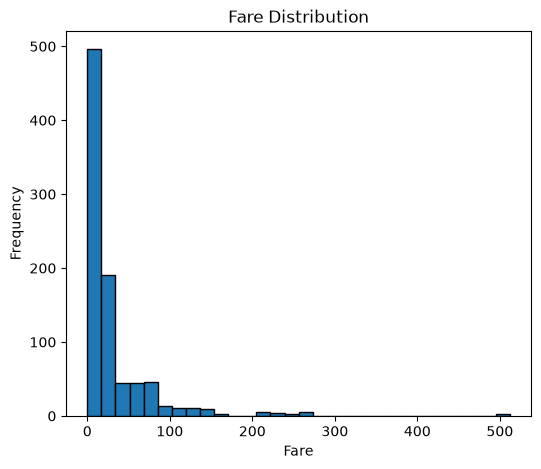

In [23]:
plt.figure(figsize=(6, 5))
plt.hist(df["fare"], bins=30, edgecolor="black")
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()

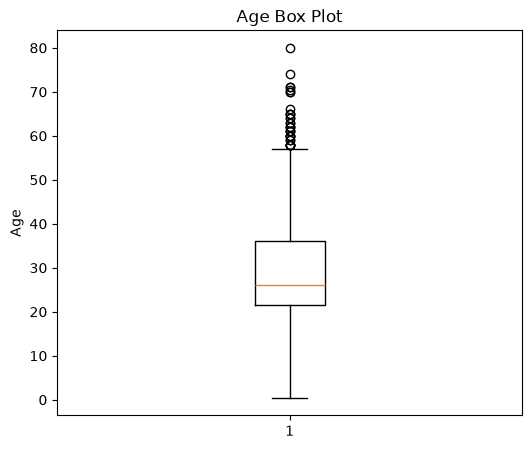

In [24]:
plt.figure(figsize=(6, 5))
plt.boxplot(df["age"])
plt.title("Age Box Plot")
plt.ylabel("Age")
plt.show()

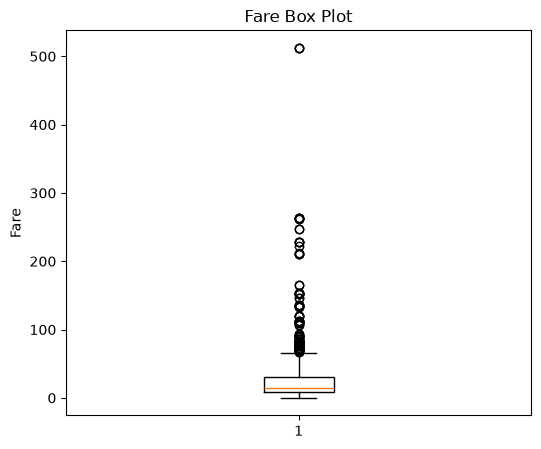

In [25]:
plt.figure(figsize=(6, 5))
plt.boxplot(df["fare"])
plt.title("Fare Box Plot")
plt.ylabel("Fare")
plt.show()

In [26]:
q1_age = df["age"].quantile(0.25)
q3_age = df["age"].quantile(0.75)
iqr_age = q3_age - q1_age

lower_bound_age = q1_age - 1.5 * iqr_age
upper_bound_age = q3_age + 1.5 * iqr_age

age_outliers = df[(df["age"] < lower_bound_age) | (df["age"] > upper_bound_age)]

print(f"Age Q1: {q1_age}, Q3: {q3_age}, IQR: {iqr_age}")
print(f"Age lower bound: {lower_bound_age}, upper bound: {upper_bound_age}")
print(f"Number of age outliers: {len(age_outliers)}")

Age Q1: 21.5, Q3: 36.0, IQR: 14.5
Age lower bound: -0.25, upper bound: 57.75
Number of age outliers: 32


In [27]:
q1_fare = df["fare"].quantile(0.25)
q3_fare = df["fare"].quantile(0.75)
iqr_fare = q3_fare - q1_fare

lower_bound_fare = q1_fare - 1.5 * iqr_fare
upper_bound_fare = q3_fare + 1.5 * iqr_fare

fare_outliers = df[(df["fare"] < lower_bound_fare) | (df["fare"] > upper_bound_fare)]

print(f"Fare Q1: {q1_fare}, Q3: {q3_fare}, IQR: {iqr_fare}")
print(f"Fare lower bound: {lower_bound_fare}, upper bound: {upper_bound_fare}")
print(f"Number of fare outliers: {len(fare_outliers)}")

Fare Q1: 7.8958, Q3: 31.0, IQR: 23.1042
Fare lower bound: -26.7605, upper bound: 65.6563
Number of fare outliers: 114
